In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


import seaborn as sns

from sklearn import preprocessing
from sklearn.datasets import make_blobs, make_classification, make_moons
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso, Ridge
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, balanced_accuracy_score

from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

## 1. Датасет

https://www.kaggle.com/datasets/vishakhdapat/price-of-used-toyota-corolla-cars

Price of Used Toyota Corolla Cars

In [2]:
df = pd.read_csv("ToyotaCorolla.csv", index_col=0)

## 2. EDA

In [3]:
df.info()

<class 'pandas.DataFrame'>
Index: 1436 entries, 1 to 1442
Data columns (total 38 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Model              1436 non-null   str  
 1   Price              1436 non-null   int64
 2   Age_08_04          1436 non-null   int64
 3   Mfg_Month          1436 non-null   int64
 4   Mfg_Year           1436 non-null   int64
 5   KM                 1436 non-null   int64
 6   Fuel_Type          1436 non-null   str  
 7   HP                 1436 non-null   int64
 8   Met_Color          1436 non-null   int64
 9   Color              1436 non-null   str  
 10  Automatic          1436 non-null   int64
 11  CC                 1436 non-null   int64
 12  Doors              1436 non-null   int64
 13  Cylinders          1436 non-null   int64
 14  Gears              1436 non-null   int64
 15  Quarterly_Tax      1436 non-null   int64
 16  Weight             1436 non-null   int64
 17  Mfr_Guarantee      1436 non-nu

In [4]:
df.head()

,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
Id,,,,,,,,,,,,,,,,,,,,,
1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,Blue,...,1,1,0,0,0,1,0,0,0,0
2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,Silver,...,0,1,0,0,0,1,0,0,0,0
3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,Blue,...,0,1,0,0,0,1,0,0,0,0
4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,Black,...,0,1,0,0,0,1,0,0,0,0
5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,Black,...,1,1,0,1,0,1,0,0,0,0


In [5]:
df.shape

(1436, 38)

In [6]:
df.isna().sum()

Model                0
Price                0
Age_08_04            0
Mfg_Month            0
Mfg_Year             0
KM                   0
Fuel_Type            0
HP                   0
Met_Color            0
Color                0
Automatic            0
CC                   0
Doors                0
Cylinders            0
Gears                0
Quarterly_Tax        0
Weight               0
Mfr_Guarantee        0
BOVAG_Guarantee      0
Guarantee_Period     0
ABS                  0
Airbag_1             0
Airbag_2             0
Airco                0
Automatic_airco      0
Boardcomputer        0
CD_Player            0
Central_Lock         0
Powered_Windows      0
Power_Steering       0
Radio                0
Mistlamps            0
Sport_Model          0
Backseat_Divider     0
Metallic_Rim         0
Radio_cassette       0
Parking_Assistant    0
Tow_Bar              0
dtype: int64

In [7]:
df = df.drop_duplicates()
df.shape

(1435, 38)

Таблица ниже потребуется для работы с признакми и их изменения

In [8]:
df1 = pd.DataFrame([
    [col, df[col].dtype, df[col].nunique()] 
    for col in df.columns
], columns=['Column', 'Dtype', 'Unique_Count'])
df1

,Column,Dtype,Unique_Count
0,Model,str,319
1,Price,int64,236
2,Age_08_04,int64,77
3,Mfg_Month,int64,12
4,Mfg_Year,int64,7
5,KM,int64,1263
6,Fuel_Type,str,3
7,HP,int64,12
8,Met_Color,int64,2
9,Color,str,10


In [9]:
df1[df1['Unique_Count'] >2][df1['Dtype'] == 'int64']['Column'].to_numpy()

C:\Users\admin\AppData\Local\Temp\ipykernel_13984\2311946563.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df1[df1['Unique_Count'] >2][df1['Dtype'] == 'int64']['Column'].to_numpy()


array(['Price', 'Age_08_04', 'Mfg_Month', 'Mfg_Year', 'KM', 'HP', 'CC',
       'Doors', 'Gears', 'Quarterly_Tax', 'Weight', 'Guarantee_Period'],
      dtype=object)

Расширенная статистика по числовым колонкам с множественными значениями(отлично от 0 или 1)

In [10]:
numeric_columns = ['Price', 'Age_08_04', 'Mfg_Month', 'Mfg_Year', 'KM', 'HP', 'CC',
       'Doors', 'Gears', 'Quarterly_Tax', 'Weight', 'Guarantee_Period']
result_numeric = df.loc[:, numeric_columns]

stats = result_numeric.agg(['min', 'max', 'mean', 'median'])
modes = result_numeric.mode().iloc[0]
stats.loc['mode'] = modes
stats

,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,CC,Doors,Gears,Quarterly_Tax,Weight,Guarantee_Period
min,4350.000000,1.000000,1.000000,1998.0000,1.000000,69.000000,1300.000000,2.000000,3.000000,19.000000,1000.000000,3.000000
max,32500.000000,80.000000,12.000000,2004.0000,243000.000000,192.000000,16000.000000,5.000000,6.000000,283.000000,1615.000000,36.000000
mean,10720.915679,55.980488,5.551916,1999.6223,68571.782578,101.491986,1576.560976,4.032753,5.026481,87.020209,1072.287108,3.816028
median,9900.000000,61.000000,5.000000,1999.0000,63451.000000,110.000000,1600.000000,4.000000,5.000000,85.000000,1070.000000,3.000000
mode,8950.000000,68.000000,1.000000,1999.0000,36000.000000,110.000000,1600.000000,5.000000,5.000000,85.000000,1075.000000,3.000000


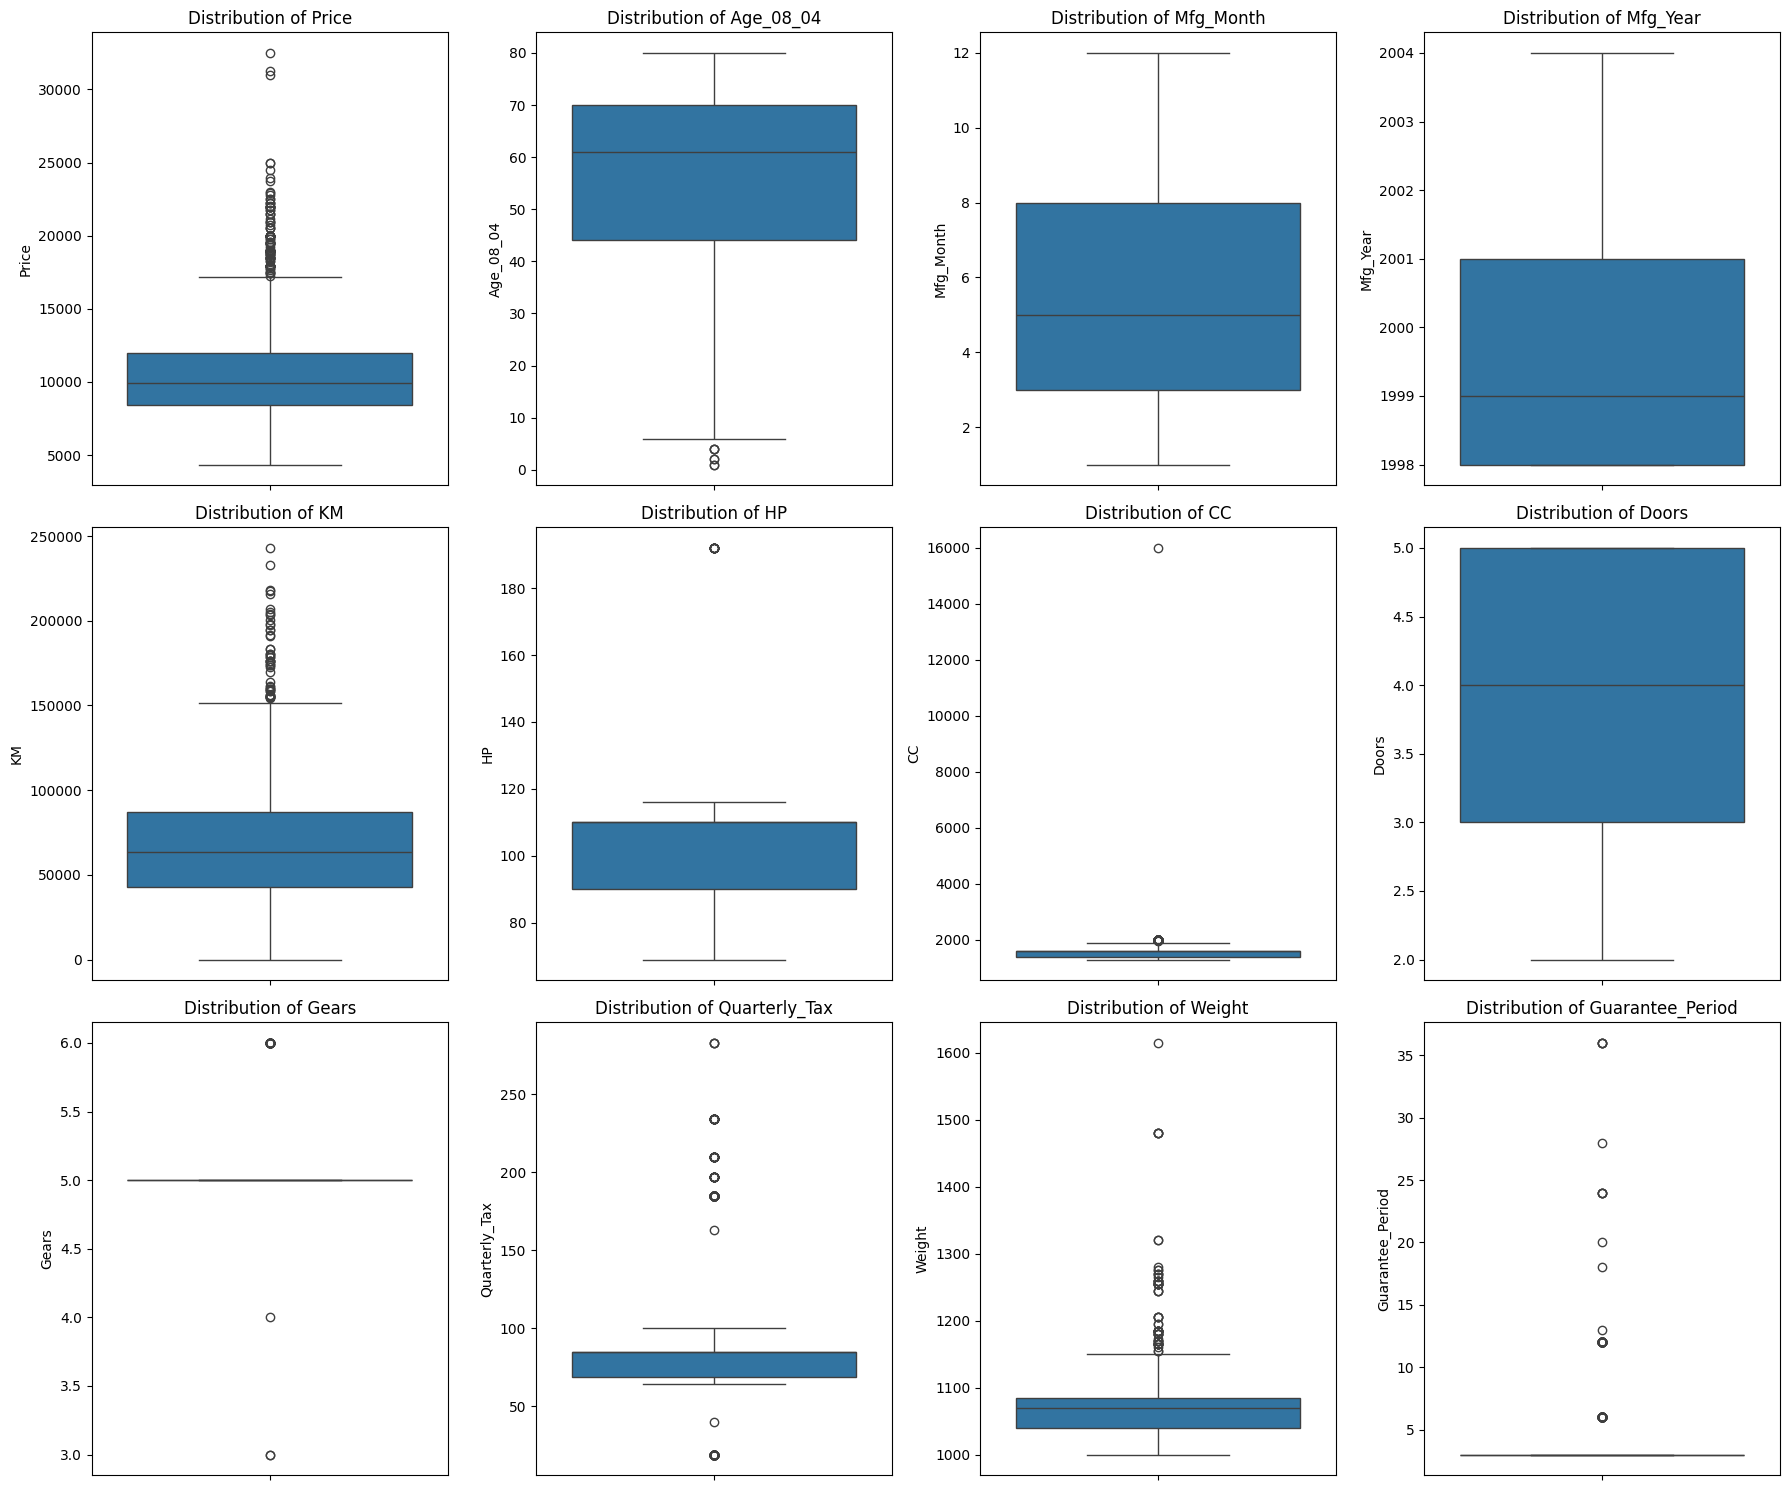

In [11]:
plt.figure(figsize=(18, 15))



for i, column in enumerate(numeric_columns, 1): 
    plt.subplot(3, 4, i)
    sns.boxplot(data=df, y=column) 
    plt.title(f'Distribution of {column}')

plt.tight_layout()
plt.show()

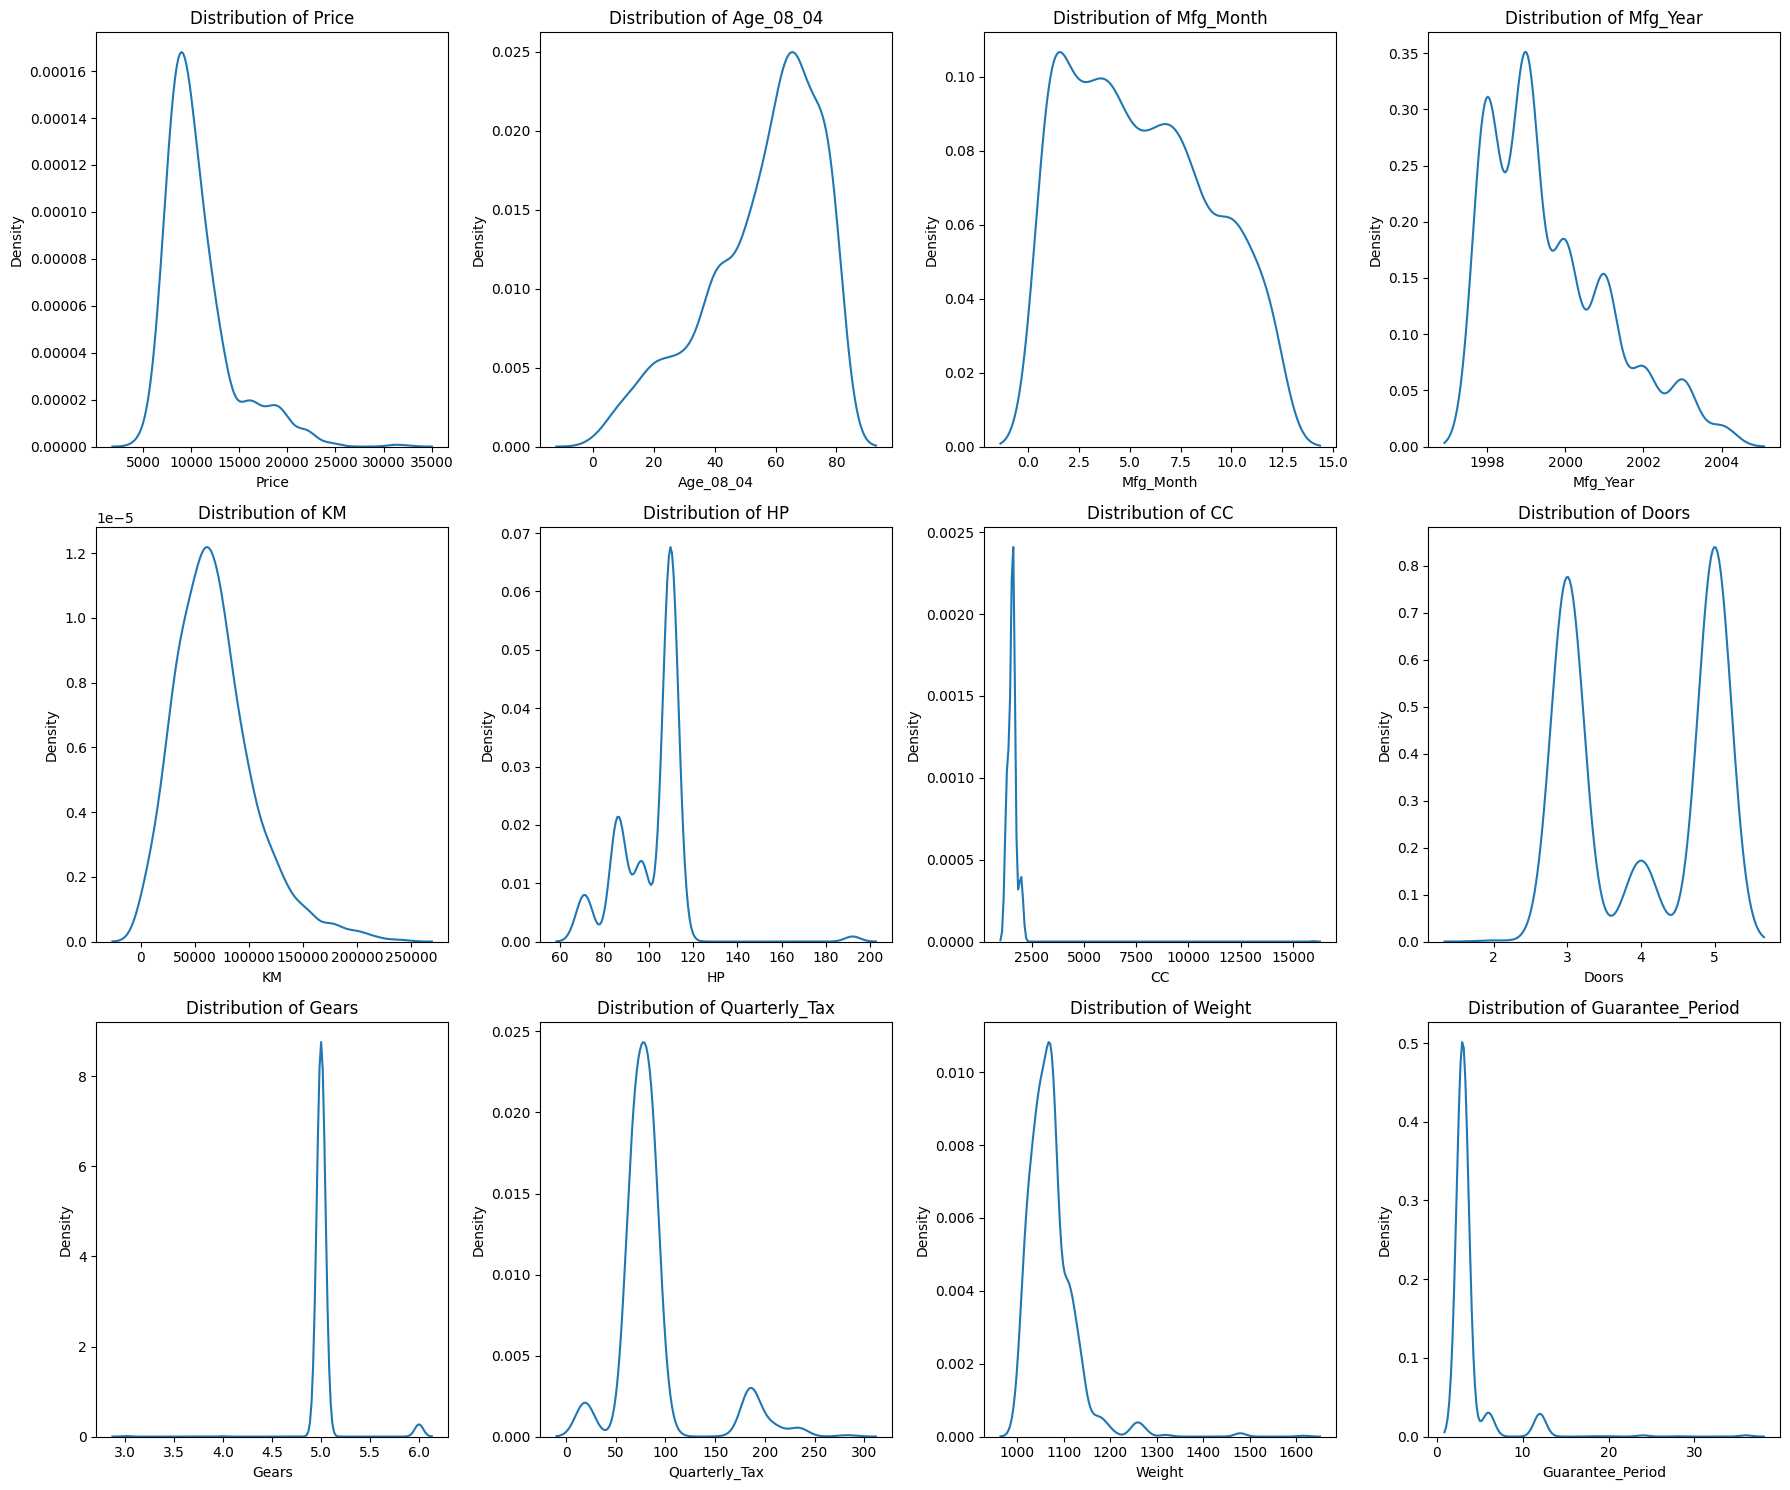

In [12]:
plt.figure(figsize=(18, 15))



for i, column in enumerate(numeric_columns, 1): 
    plt.subplot(3, 4, i)
    sns.kdeplot(data=df, x=column) 
    plt.title(f'Distribution of {column}')

plt.tight_layout()
plt.show()

По цене много выбросов, и это столбец предсказаний, видимо удалять выбросы, тк логарифмирование не помогло от выбросов

Age_08_04 смещены и есть выбросы в нуле

Mfg_year смещены, есть много малых значений

KM - выбросы логичны, менять не стоит

HP выброс 1 и смещены данные

CC - выброс есть, лучше удалить
Gears - так и должно быть
Quartetrly_Tax - выбросы
weight - выбросы
guarantee_period - дискретный признак, норм


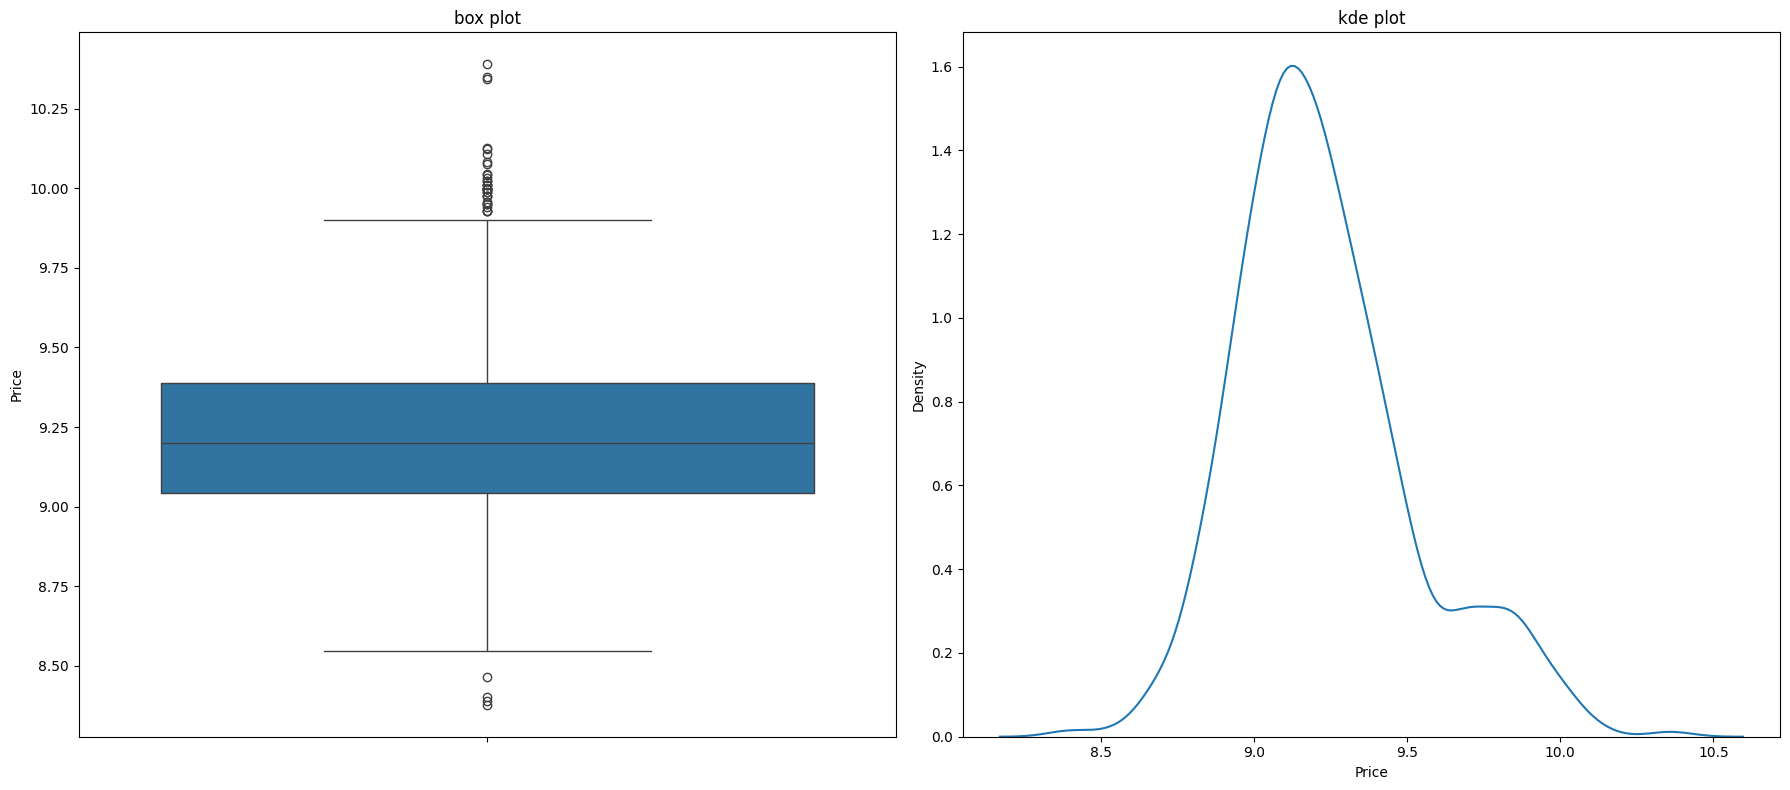

In [13]:
df2 = df.copy()
df2['Price'] = np.log1p(df2['Price'])
plt.figure(figsize=(18, 8))
plt.subplot(1, 2, 1)
plt.title(f'box plot')
sns.boxplot(data=df2, y='Price')

plt.subplot(1, 2, 2)
plt.title(f'kde plot')
sns.kdeplot(data=df2, x='Price')

plt.tight_layout()
plt.show()
                        

решение что делать с выбросами:

удалить 5 процентов сверху у 'Price','Age_08_04', 'KM', 'Weight', 'HP', 'CC'

In [14]:
df_clean = df.copy()
cols_to_trim_up = ['Price', 'KM', 'Weight', 'HP', 'CC']


limits = {}

for col in cols_to_trim_up:
    limits[f'{col}_up'] = df[col].quantile(0.95)



mask = pd.Series([True] * len(df), index=df.index)

for col in cols_to_trim_up:
    mask &= (df[col] <= limits[f'{col}_up'])

df_clean = df[mask].copy()

print(f"Было радкоў: {len(df)}, стала пасля чысткі: {len(df_clean)}")
print(f"Выдалена ўсяго: {len(df) - len(df_clean)} радкоў")


Было радкоў: 1435, стала пасля чысткі: 1260
Выдалена ўсяго: 175 радкоў


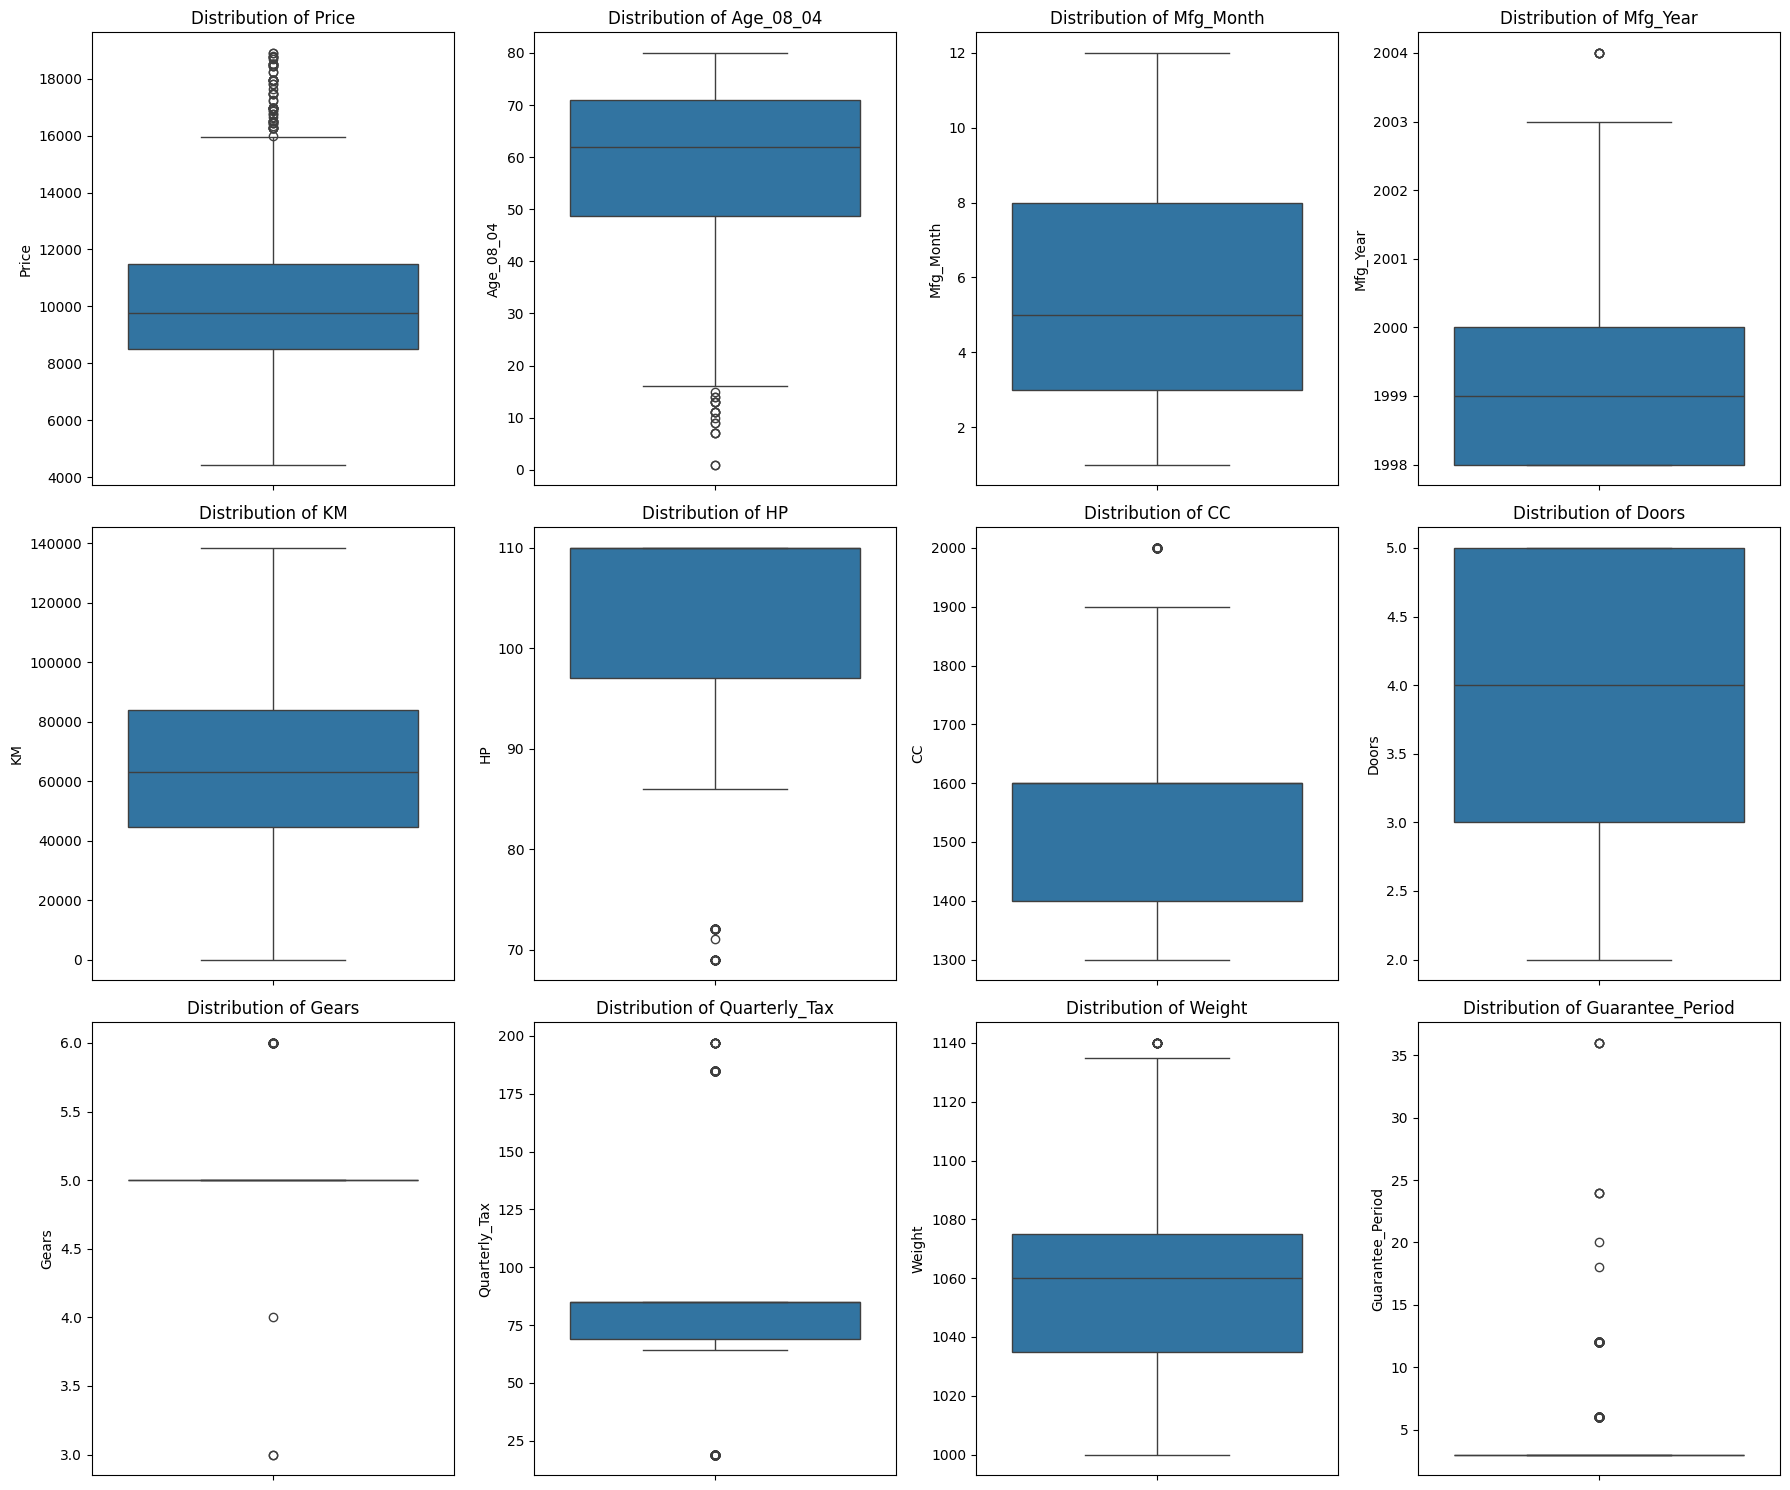

In [15]:
plt.figure(figsize=(18, 15))



for i, column in enumerate(numeric_columns, 1): 
    plt.subplot(3, 4, i)
    sns.boxplot(data=df_clean, y=column) 
    plt.title(f'Distribution of {column}')

plt.tight_layout()
plt.show()

Корреляция:

<Axes: >

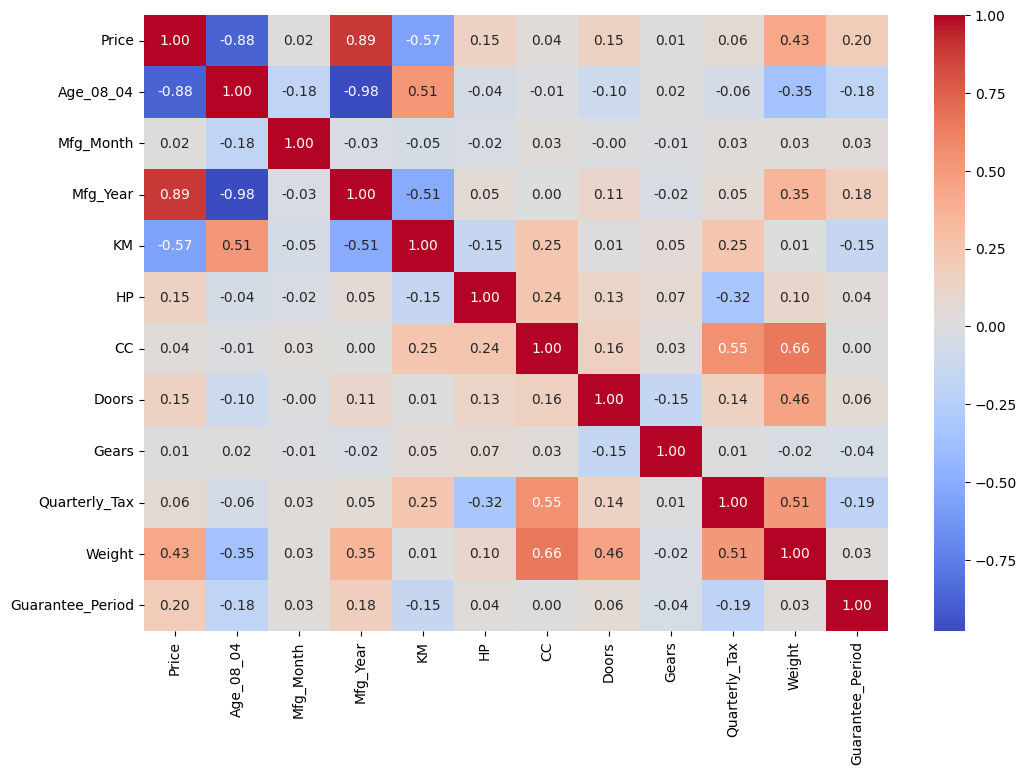

In [16]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_clean[numeric_columns].corr(), annot=True, cmap='coolwarm', fmt=".2f")

По матрице корреляции:

обратная линейная зависимость между Mfg_Year и Age_08_04 - одно из них необходимо удалить

Также видна линейная зависимость между таргетом price и Mfg_Year и KM

### Вопросы:

- Как вы предобрабатывали данные?

удалить выбросы, дубликаты как 5 процентов свреху

- Что вы поняли, проведя EDA?

в датасете много выбросов, многие признаки смещены, есть категориальные признаки, есть линейная зависисмоть между признаками.


## 3. Работа с признаками

Как описано выше удалим признаки Mfg_Month и Mfg_Year, тк Age_08_04: The age of the car in months as of August 2004 достаточно
и удаляется Mfg_Year изза скореллированности признаков 

In [17]:
df_clean = df_clean.drop(columns=['Mfg_Month', 'Mfg_Year'])

In [18]:
df1 = pd.DataFrame([
    [col, df_clean[col].dtype, df_clean[col].nunique()] 
    for col in df_clean.columns
], columns=['Column', 'Dtype', 'Unique_Count'])
df1

,Column,Dtype,Unique_Count
0,Model,str,255
1,Price,int64,191
2,Age_08_04,int64,72
3,KM,int64,1112
4,Fuel_Type,str,3
5,HP,int64,9
6,Met_Color,int64,2
7,Color,str,10
8,Automatic,int64,2
9,CC,int64,10


In [19]:
df1[df1['Dtype']=='str']

,Column,Dtype,Unique_Count
0,Model,str,255
4,Fuel_Type,str,3
7,Color,str,10


23 из 38 признако имеют значение 0 или 1, трогать не надо

Требуется перекодирование строковых признаков 
- Model более 300 значений - label encoding
- Fuel_Type  - one-hot encoding
- Color   - 10 значений label encoding
- Cylinders  - только одно значений, признак выкинуть

In [20]:
df_clean = df_clean.drop(columns='Cylinders')

In [21]:
''' 

one-hot encoding for fuel type with k-1 parmatrs (add 2 columns of 3)

'''

df_encoded = pd.get_dummies(df_clean, columns=['Fuel_Type'], drop_first=True, dtype=int)

In [22]:
df_encoded.shape

(1260, 36)

In [23]:
label_encoder = preprocessing.LabelEncoder()

df_encoded['Model']= label_encoder.fit_transform(df_encoded['Model'])+1

df_encoded['Model'].unique()

array([219, 190, 120,  96,  95,  74,  52,  51,  50,  57,  56, 107,  98,
       183,  62,  53, 100,  99,  71, 129,  69,  97, 187, 186,  55, 205,
         2, 204, 114,  54,  63,  75, 208, 184, 209, 216, 222, 226, 225,
        59, 111, 218, 228, 103, 109, 108, 180, 112, 115, 105,  60, 253,
        58, 192, 220, 110, 101,  81, 119, 137, 178, 207, 212, 116, 171,
        72,  66, 130, 176, 102, 197, 215, 211, 106, 181, 113, 198,  15,
       191, 169,  73, 224, 233, 217, 221, 239,  85, 128, 146, 231,   8,
       247, 185, 152,  68, 134, 133, 223,   5,  61, 117, 202, 175, 227,
       254,  83,   1,  67, 189, 122,  64,  87,  27,  41, 251, 148, 104,
        13,  79, 123,  65,  24, 246,  70,  76, 230, 240, 234, 188,  93,
        94, 135, 124,   6,  14,  77, 237, 159, 142,  17,  35,  23, 235,
        43,  21, 144, 206, 136, 162,  91,  16, 179, 126,  88, 255, 143,
       194,  34,  28,  80, 151, 168,   3, 131, 125,  11, 173,   9, 242,
        10,  92,  46, 249,   7, 213, 165, 145,  22, 244, 195, 11

In [24]:
label_encoder = preprocessing.LabelEncoder()

df_encoded['Color'] = label_encoder.fit_transform(df_encoded['Color'])+1

df_encoded['Color'].unique()

array([ 3,  5,  2,  7,  4,  6, 10,  9,  8,  1])

In [25]:
df1[(df1['Unique_Count']>2)&(df1['Dtype'] =='int64')]

,Column,Dtype,Unique_Count
1,Price,int64,191
2,Age_08_04,int64,72
3,KM,int64,1112
5,HP,int64,9
9,CC,int64,10
10,Doors,int64,4
12,Gears,int64,4
13,Quarterly_Tax,int64,7
14,Weight,int64,37
17,Guarantee_Period,int64,7


Маштабирование:

Для признаков
- KM	(standartscaler)
- HP (RobustScaler)
- CC	(RobustScaler)
- Quarterly_Tax	(RobustScaler)
- Weight (standartscaler)
- Guarantee_Period (RobustScaler)

тк где мало уникальных значений, там дискретный вид, и данные не распределены нормально, то нормализация не сохранит ценной информации, лучше RobustScaler устойчивый к выбросам

Само маштабирование будет проделано после разделения выборки на обучающую и тестовую

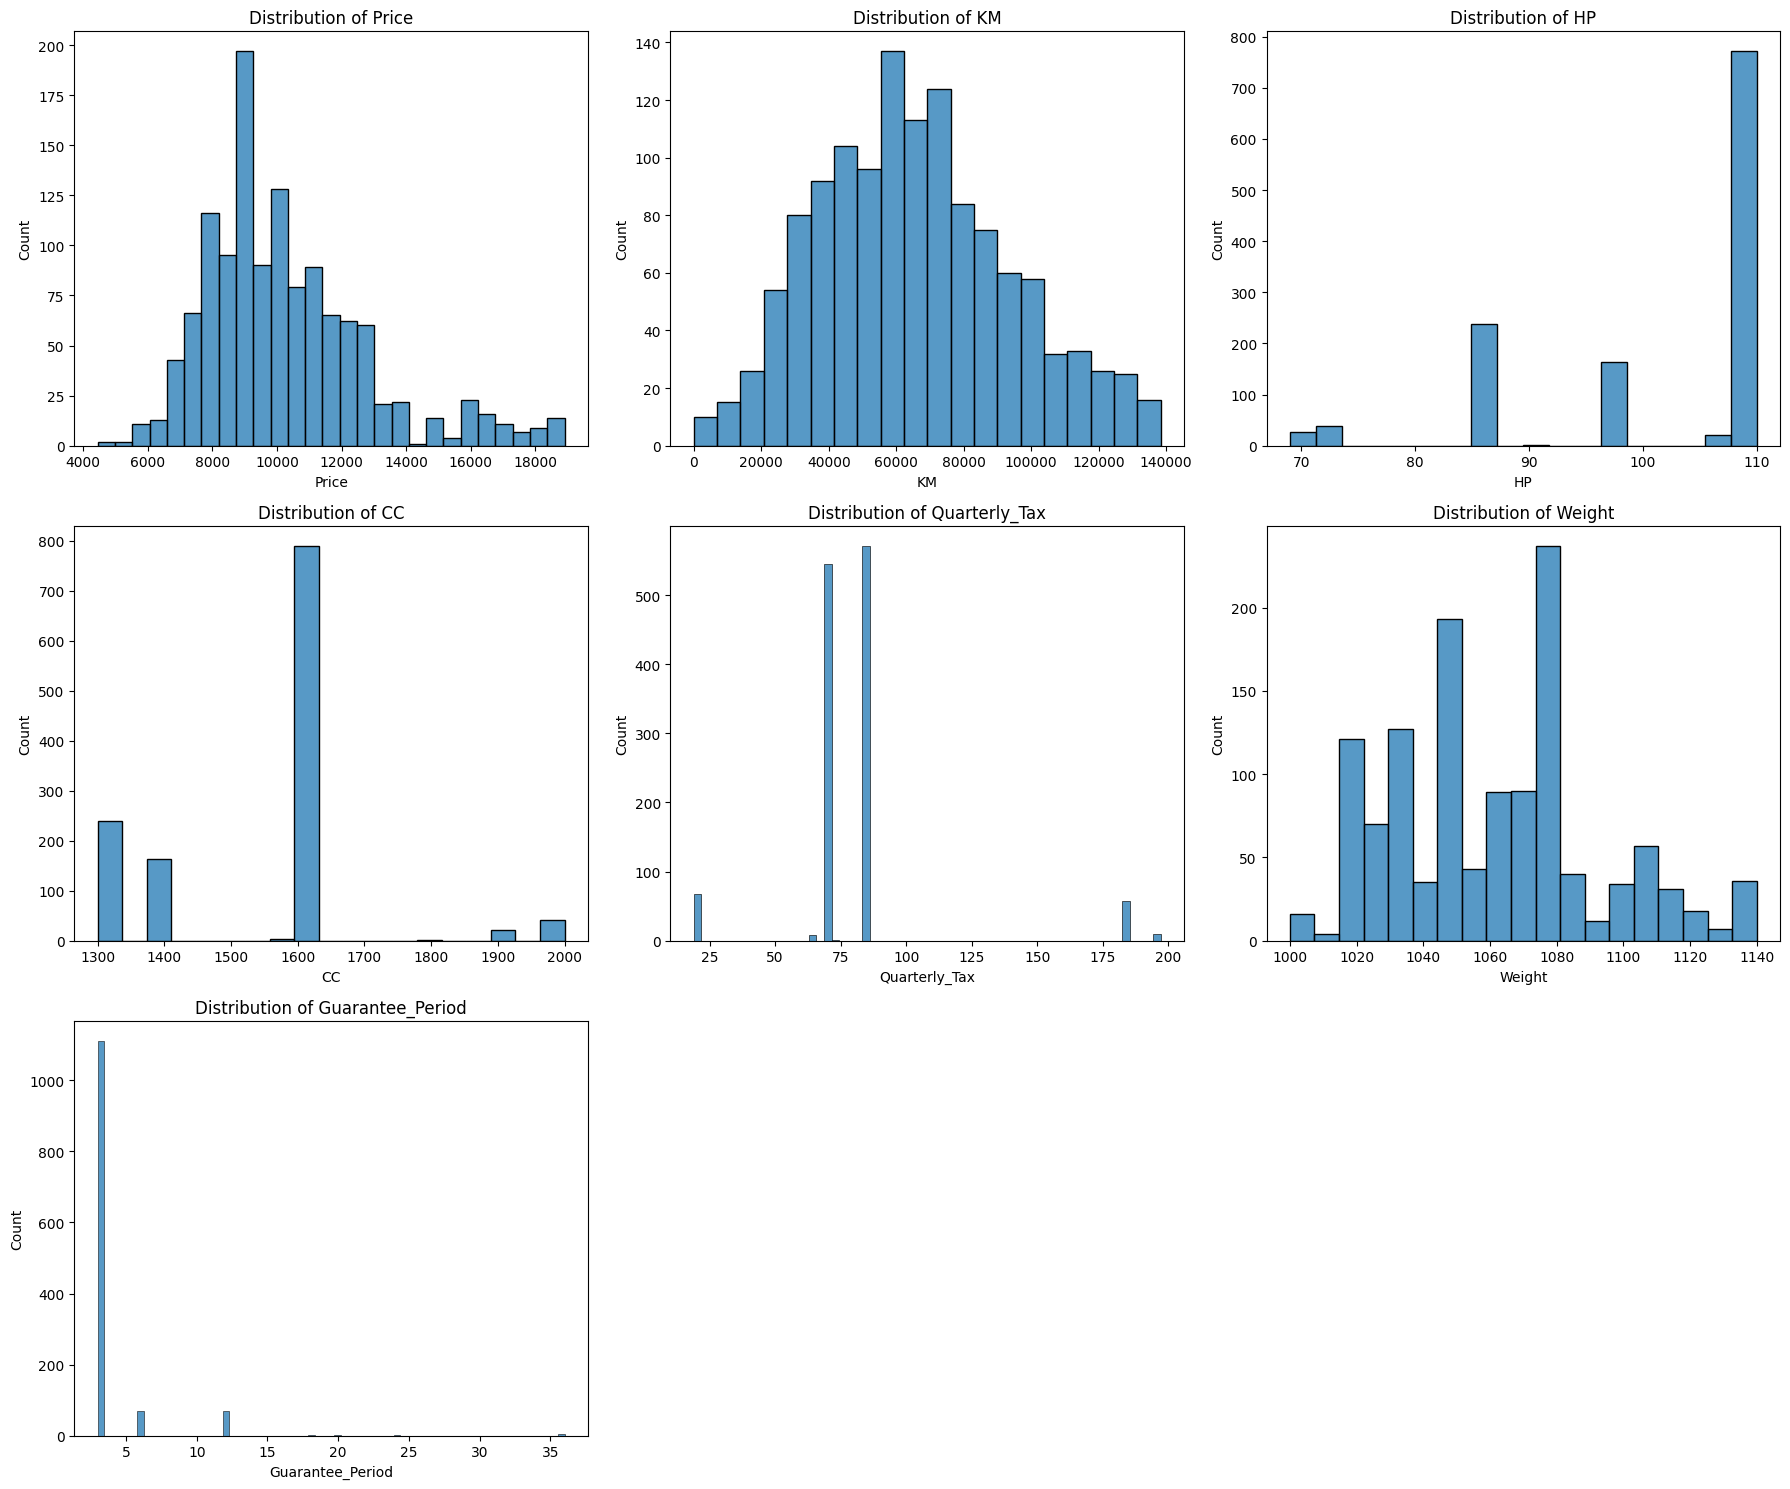

In [26]:
plt.figure(figsize=(18, 15))



for i, column in enumerate(['Price','KM', 'HP', 'CC', 'Quarterly_Tax', 'Weight', 'Guarantee_Period'], 1): 
    plt.subplot(3, 3, i)
    sns.histplot(data=df_encoded, x=column)
    plt.title(f'Distribution of {column}')

plt.tight_layout()
plt.show()

### Вопросы:
- Как вы работали с признаками?

Оценка количества значений(2 или больше), кодирование категориальных

- Какие признаки вы добавили / изменили и почему?

Закодировали категориальные в one-hot encoding и label encoding (со сдвигом, чтобы первая метка была 1, а не 0)

- Какие признаки вы удалили и почему?

Удалили Mfg_Month и Mfg_Year, поскольку между Mfg_Year и Age_08_04 есть обратная линейная зависимость, а Age_08_04 = (Mfg_Year-1998)+Mfg_Month, лучше оставить 1 признак, вместо 2 идентичных

удалили Cylinders, как бесполезный признак с одним значением


## 4. Разделение выборки

Разделение выборки на тестовую и обучающую

In [27]:
X = df_encoded.drop(columns='Price')
y = df_encoded['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((882, 35), (378, 35), (882,), (378,))

Подготовка данных и наконец-то маштабирование:
- KM	(standartscaler)
- HP (RobustScaler)
- CC	(RobustScaler)
- Quarterly_Tax	(RobustScaler)
- Weight (standartscaler)
- Guarantee_Period (RobustScaler)

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


robust_cols = ['HP', 'CC', 'Quarterly_Tax', 'Guarantee_Period']

standard_cols = ['Weight', 'KM']


preprocessor = ColumnTransformer([
('std', StandardScaler(), standard_cols),
('rob', RobustScaler(), robust_cols),
], remainder='passthrough')

x_train_transformed = preprocessor.fit_transform(X_train)
x_test_transformed = preprocessor.transform(X_test)


### Вопросы:

- Как именно вы разделили выборку?

Train, test

- Для чего это нужно? Зачем мы вообще отделяем часть данных и почему нельзя обучать и проверять модель на одном и том же наборе?

Утчека данных получится с завышенным результатом.

## 5. Обучение моделей

Функция для печати оценок:

In [29]:
def print_score(y_test, y_pred):
    mae = metrics.mean_absolute_error(y_test, y_pred)
    mse = metrics.mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = metrics.r2_score(y_test, y_pred)

    print(f"MAE (Средняя абсолютная ошибка): {mae:.2f}")
    print(f"RMSE (Корень из среднеквадратичной ошибки): {rmse:.2f}")
    print(f"R² (Коэффициент детерминации): {r2:.2f}")

Обучение базовой линейной регрессии:

In [30]:
reg = LinearRegression()

reg.fit(x_train_transformed, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [31]:
print("model score: %.3f" % reg.score(x_test_transformed, y_test))

model score: 0.851


In [32]:
y_pred = reg.predict(x_test_transformed)

In [33]:
print_score(y_test, y_pred)

MAE (Средняя абсолютная ошибка): 769.78
RMSE (Корень из среднеквадратичной ошибки): 981.90
R² (Коэффициент детерминации): 0.85


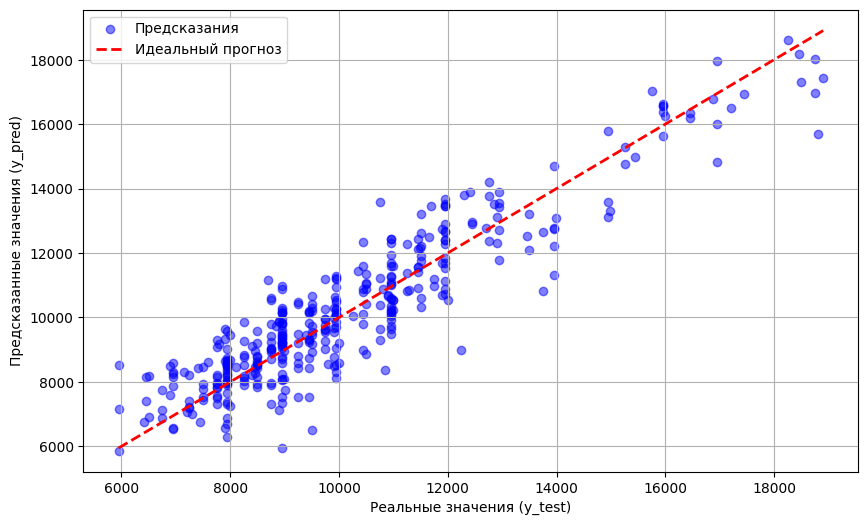

In [34]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, alpha=0.5, color='blue', label='Предсказания')

line_coords = [y_test.min(), y_test.max()]
plt.plot(line_coords, line_coords, color='red', linestyle='--', linewidth=2, label='Идеальный прогноз')

plt.xlabel('Реальные значения (y_test)')
plt.ylabel('Предсказанные значения (y_pred)')
plt.legend()
plt.grid(True)
plt.show()

Обучение модели с регуляризацией:

L1:

In [ ]:
lasso = Lasso()
lasso.fit(x_train_transformed, y_train)
print("model score: %.3f" % lasso.score(x_test_transformed, y_test))
y_pred1 = lasso.predict(x_test_transformed)

model score: 0.852


In [100]:
print_score(y_test, y_pred1)

MAE (Средняя абсолютная ошибка): 766.75
RMSE (Корень из среднеквадратичной ошибки): 980.16
R² (Коэффициент детерминации): 0.85


Ниже напечатаны коэфициенты, часть из них занулилась - что и является свойством L1 регуляризация - выбор признаков

In [37]:
list(zip(df.columns,lasso.coef_))

[('Model', np.float64(538.9001860362937)),
 ('Price', np.float64(-399.6904045004988)),
 ('Age_08_04', np.float64(-204.86705726509106)),
 ('Mfg_Month', np.float64(-11.313172722135114)),
 ('Mfg_Year', np.float64(269.3863767801699)),
 ('KM', np.float64(71.67115463068299)),
 ('Fuel_Type', np.float64(1.1835878056309304)),
 ('HP', np.float64(-100.31909070675988)),
 ('Met_Color', np.float64(-24.765871850878565)),
 ('Color', np.float64(-39.81676466336651)),
 ('Automatic', np.float64(-0.0)),
 ('CC', np.float64(-95.51275999303765)),
 ('Doors', np.float64(194.48195959673967)),
 ('Cylinders', np.float64(320.45973638734336)),
 ('Gears', np.float64(400.5311924218567)),
 ('Quarterly_Tax', np.float64(36.6116129808338)),
 ('Weight', np.float64(0.0)),
 ('Mfr_Guarantee', np.float64(-150.08159048934198)),
 ('BOVAG_Guarantee', np.float64(285.69930288315703)),
 ('Guarantee_Period', np.float64(1432.107536688066)),
 ('ABS', np.float64(64.95402697884406)),
 ('Airbag_1', np.float64(240.5148040421846)),
 ('Airba

L2:

In [38]:
ridge = Ridge()

ridge.fit(x_train_transformed, y_train)
print("model score: %.3f" % ridge.score(x_test_transformed, y_test))
y_pred2 = ridge.predict(x_test_transformed)
print_score(y_test, y_pred2)

model score: 0.851
MAE (Средняя абсолютная ошибка): 767.48
RMSE (Корень из среднеквадратичной ошибки): 980.78
R² (Коэффициент детерминации): 0.85


In [49]:
alphas = np.arange(1, 500, 50)
coefs_lasso = np.zeros((alphas.shape[0], x_train_transformed.shape[1])) # матрица весов размера (число регрессоров) x (число признаков)
coefs_ridge = np.zeros((alphas.shape[0], x_train_transformed.shape[1]))

for i, item in enumerate(alphas):
    lasso = Lasso(alpha = alphas[i])

    lasso.fit(x_train_transformed, y_train)
    coefs_lasso[i,:] = lasso.coef_

for i, item in enumerate(alphas):
    
    ridge = Ridge(alpha=alphas[i])

    ridge.fit(x_train_transformed, y_train)
    coefs_ridge[i,:] = ridge.coef_

Text(0.5, 1.0, 'Ridge')

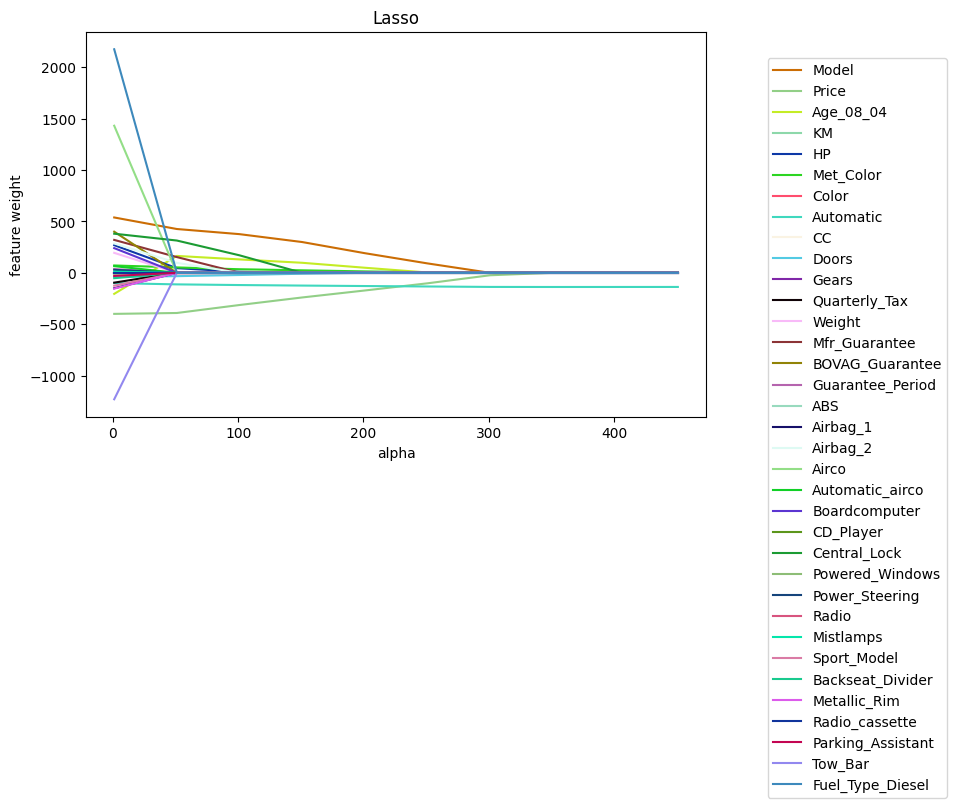

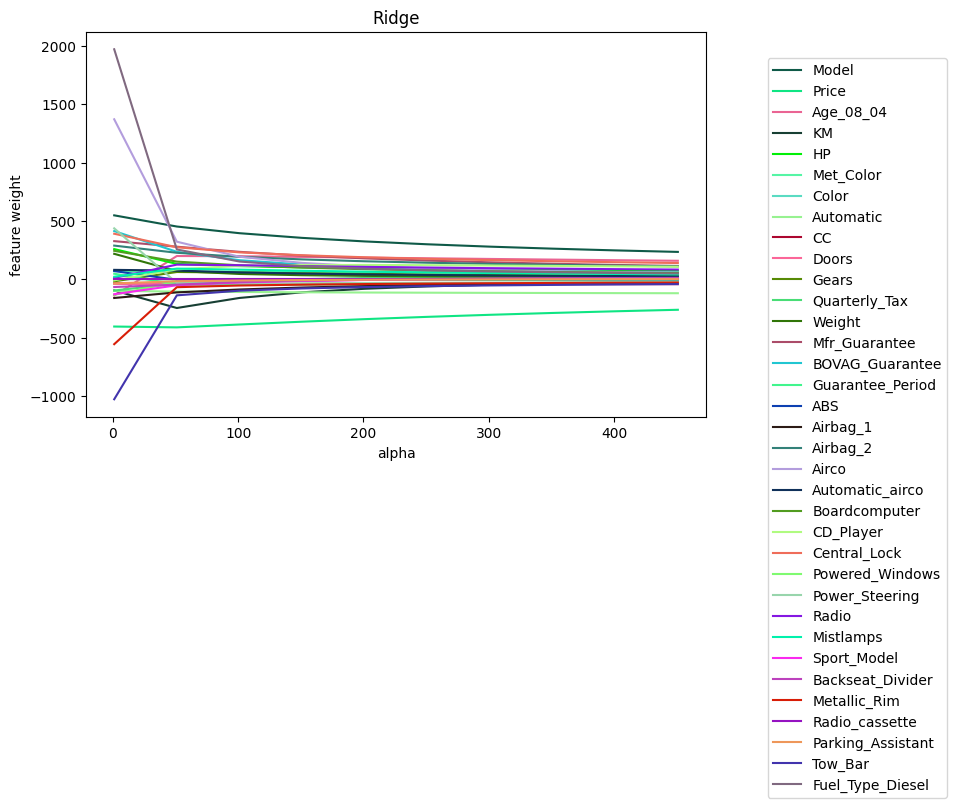

In [50]:
plt.figure(figsize=(8, 5))
for coef, feature in zip(coefs_lasso.T, df_encoded.columns):
    plt.plot(alphas, coef, label=feature, color=np.random.rand(3))
plt.legend(loc="upper right", bbox_to_anchor=(1.4, 0.95))
plt.xlabel("alpha")
plt.ylabel("feature weight")
plt.title("Lasso")

plt.figure(figsize=(8, 5))
for coef, feature in zip(coefs_ridge.T, df_encoded.columns):
    plt.plot(alphas, coef, label=feature, color=np.random.rand(3))
plt.legend(loc="upper right", bbox_to_anchor=(1.4, 0.95))
plt.xlabel("alpha")
plt.ylabel("feature weight")
plt.title("Ridge")

Все круто, но как требуется альфа

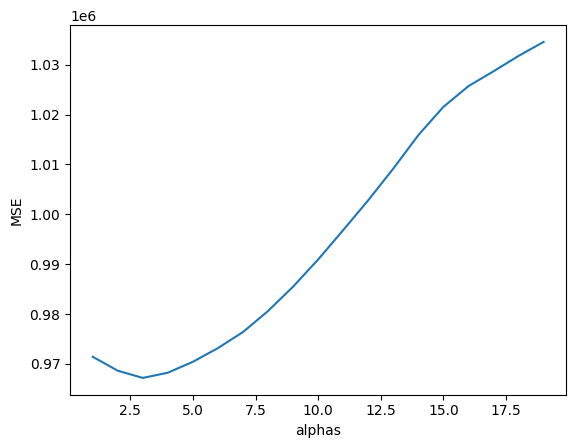

Выбранное alpha: 3 

Вектор коэффициентов для выбранного alpha:


[('Model', np.float64(533.0371882535917)),
 ('Price', np.float64(-403.87942436916495)),
 ('Age_08_04', np.float64(38.460854325572996)),
 ('KM', np.float64(-276.19784559538397)),
 ('HP', np.float64(248.9546384729969)),
 ('Met_Color', np.float64(72.21934848902579)),
 ('Color', np.float64(0.9225528439823538)),
 ('Automatic', np.float64(-100.9848561722574)),
 ('CC', np.float64(-21.25171095414068)),
 ('Doors', np.float64(-40.684198134154926)),
 ('Gears', np.float64(0.0)),
 ('Quarterly_Tax', np.float64(-90.71640556912661)),
 ('Weight', np.float64(123.34897630626685)),
 ('Mfr_Guarantee', np.float64(315.83734107642596)),
 ('BOVAG_Guarantee', np.float64(375.3928700628599)),
 ('Guarantee_Period', np.float64(0.0)),
 ('ABS', np.float64(0.0)),
 ('Airbag_1', np.float64(-109.38122528454352)),
 ('Airbag_2', np.float64(279.89621518739307)),
 ('Airco', np.float64(1334.4476988151584)),
 ('Automatic_airco', np.float64(27.546821025482238)),
 ('Boardcomputer', np.float64(217.71553389651748)),
 ('CD_Player',

In [41]:
from sklearn.linear_model import LassoCV
from sklearn.model_selection import KFold

skf = KFold(n_splits=5, shuffle=True, random_state=42)
alphas = np.arange(1, 20, 1)
regLassoCV = LassoCV(alphas=alphas, cv=skf)
regLassoCV.fit(x_train_transformed, y_train)

plt.plot(regLassoCV.alphas_, regLassoCV.mse_path_.mean(axis=1))
plt.xlabel('alphas')
plt.ylabel('MSE')
plt.show()

print('Выбранное alpha:', regLassoCV.alpha_, '\n')
print('Вектор коэффициентов для выбранного alpha:')
list(zip(df_encoded.columns, regLassoCV.coef_))

Вот часть кэфов занулилась но я не понимаю что дальше с этим делать 

- Как проходило обучение моделей?

Быстро? о чем вопрос то

- Сравнение скорости: если вы учили несколько разных моделей или использовали подбор гиперпараметров (например, коэффициента регуляризации alpha ), сравните, какая модель обучалась быстрее и почему.

одинаково.

## 6. Оценка качества и сравнение моделей

Ответьте на следующие вопросы:

1. Какие метрики вы использовали для сравнения моделей? (Обоснуйте выбор: например, почему RMSE, а не MAE, или наоборот. Зачем нужен
$R^2$?).
2. На какой части выборки вы считали метрики?
3. Какая модель по итогу справилась лучше?
4. Насколько хорошие получились результаты?
5. Чем докажете, что ваша модель не переобучилась?